[2026-07-10 13:10:09] [info     ] 计算因子，区间：2019-01-01 00:00:00 ~ 2024-1-31 23:59:59
【步骤3完成】盘口日频聚合行数：2193961

【步骤4】读取财务TTM-ROE数据并填充日频
【步骤4完成】财务填充后日频行数：1095078

【步骤5】多表合并
【步骤5完成】合并+成分股过滤后行数：1231021

【步骤6】计算子因子
【步骤6完成】全部子因子计算完毕

【步骤7】截面标准化合成总因子
===== 全部流程执行完毕，返回因子表 =====
[2026-07-10 13:12:06] [info     ] 读取因子库用于回归评估
[2026-07-10 13:12:08] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-10 13:12:22] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-10 13:12:32] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-10 13:12:45] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2019-01-02 至 2024-01-31
[2026-07-10 13:12:45] [info     ] ========== 数据检查 ==========
[2026-07-10 13:12:45] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_2

时段,IC
2020-02-03~2020-03-31,0.0293

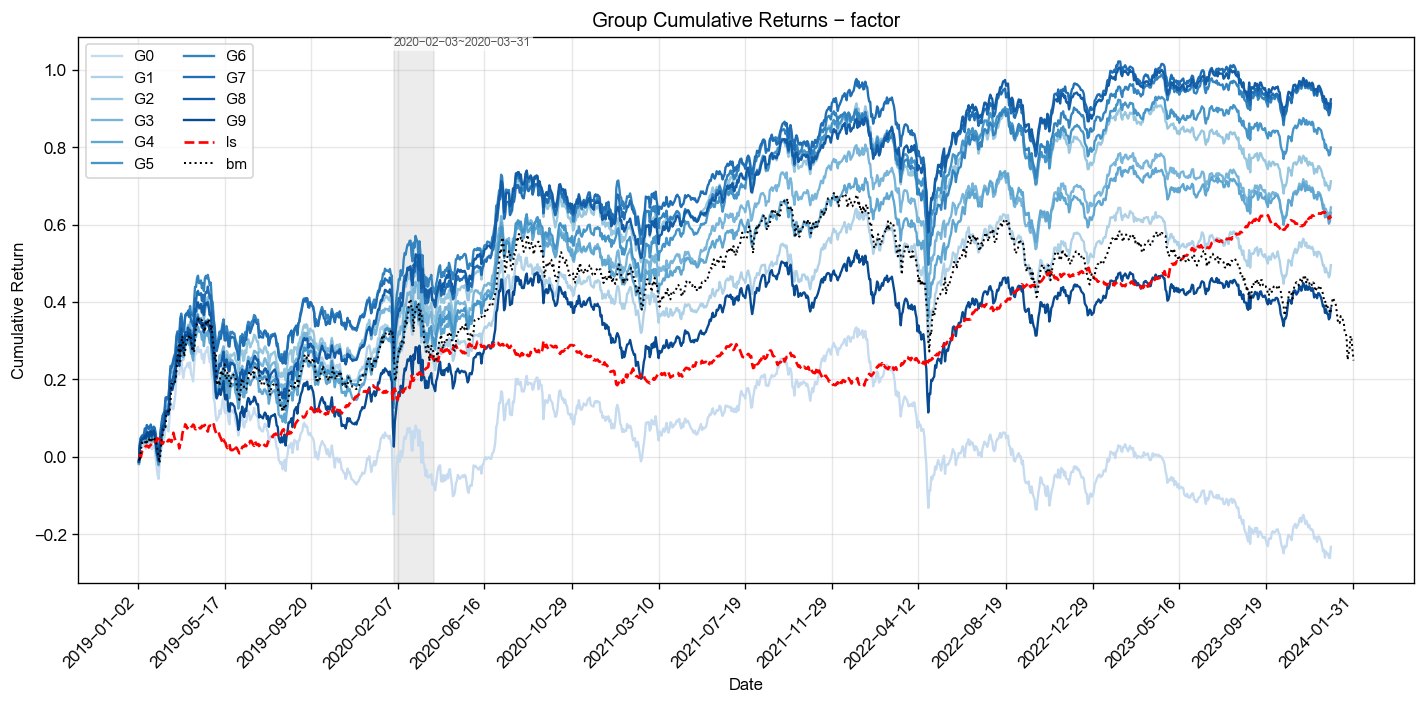
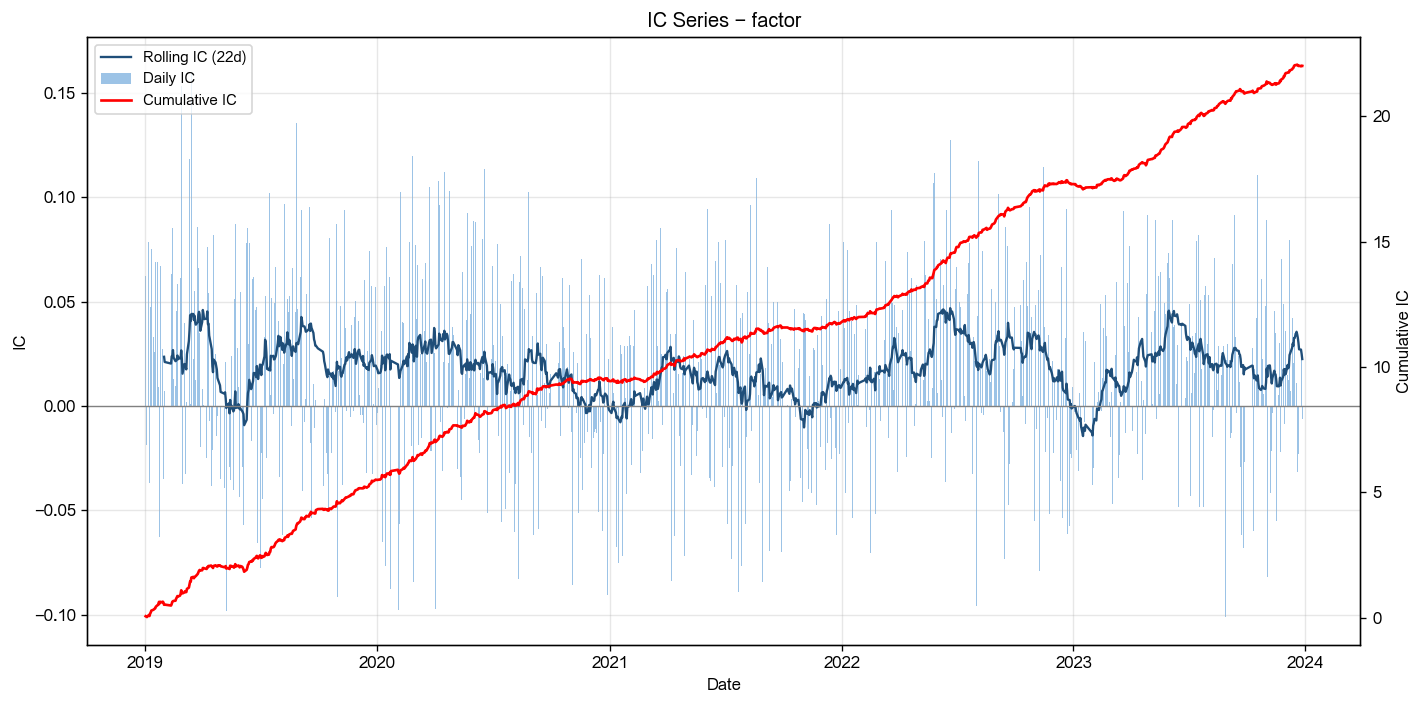
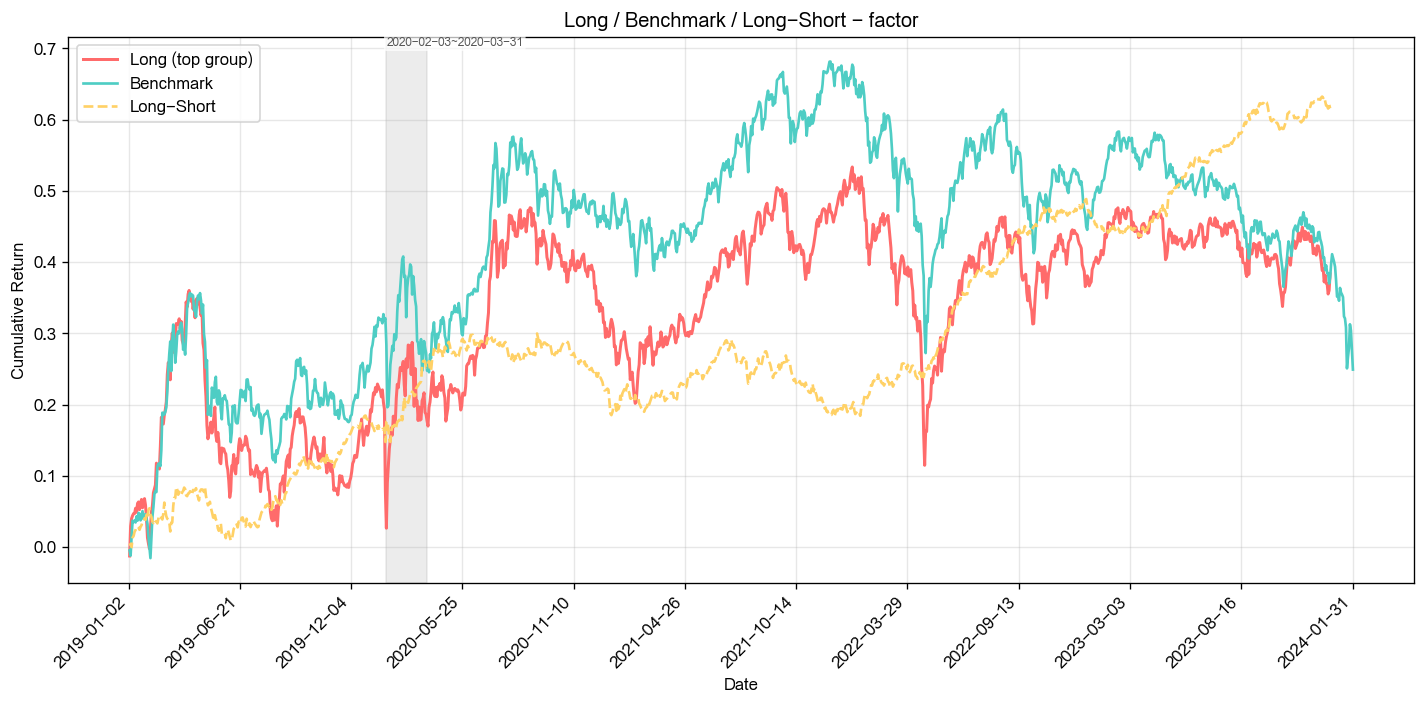
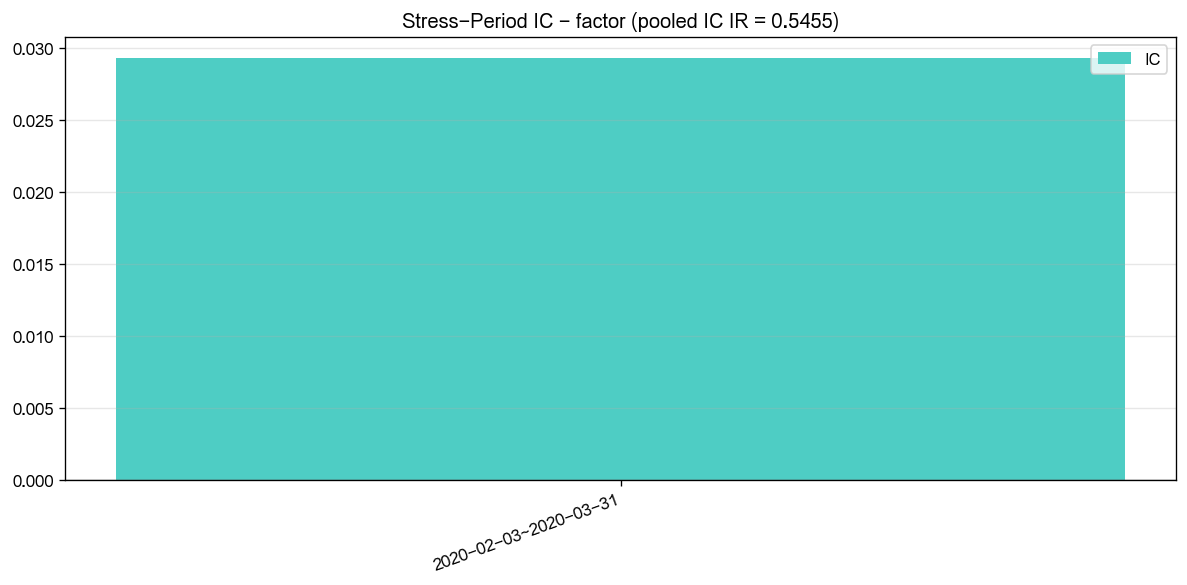
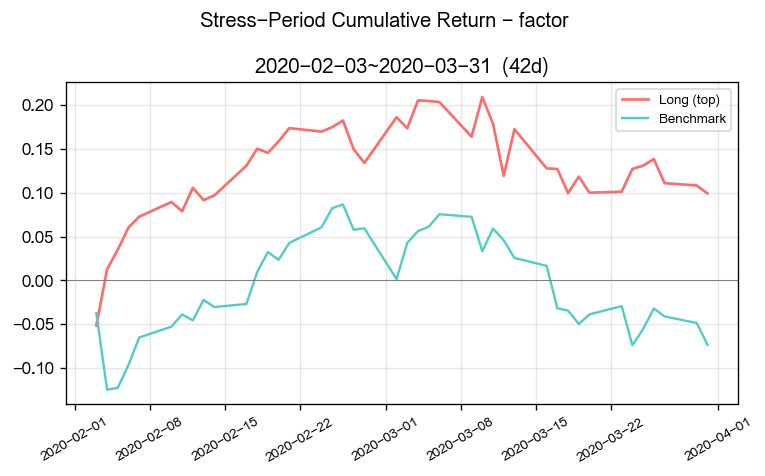

[2026-07-10 13:18:49] [info     ] ========== 因子池回归 ==========
[2026-07-10 13:18:51] [info     ] 加载 T+1 收益数据完成                  end_date=2024-01-31 instrument_count=1932 rows=2149441 start_date=2019-01-02
[2026-07-10 13:18:53] [info     ] 获取收益率数据, 耗时: 4.2601 秒
[2026-07-10 13:19:03] [info     ] 滚动 Elastic Net 拟合, 耗时: 10.3872 秒
[2026-07-10 13:19:03] [info     ] 统计 回归结果, 耗时: 0.0092 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,beta_000300SH_22,1.6403,0.0171,0.0104,0.9831
2,cci_14,1.5472,0.0326,0.0211,1.0000
3,turn,1.4812,0.0268,0.0181,0.8983
4,factor,1.3499,0.0128,0.0095,0.9492
5,ps_ttm,1.3219,0.0072,0.0054,0.9153
6,reversal_5,1.3085,0.0092,0.0070,0.9492
7,kdj_d_9_3_3,1.3065,0.0278,0.0213,0.8814
8,momentum_5,1.3046,0.0177,0.0136,0.9492
9,volatility_5,1.3038,0.0119,0.0092,0.9322
10,list_days,1.2991,0.0100,0.0077,0.9661

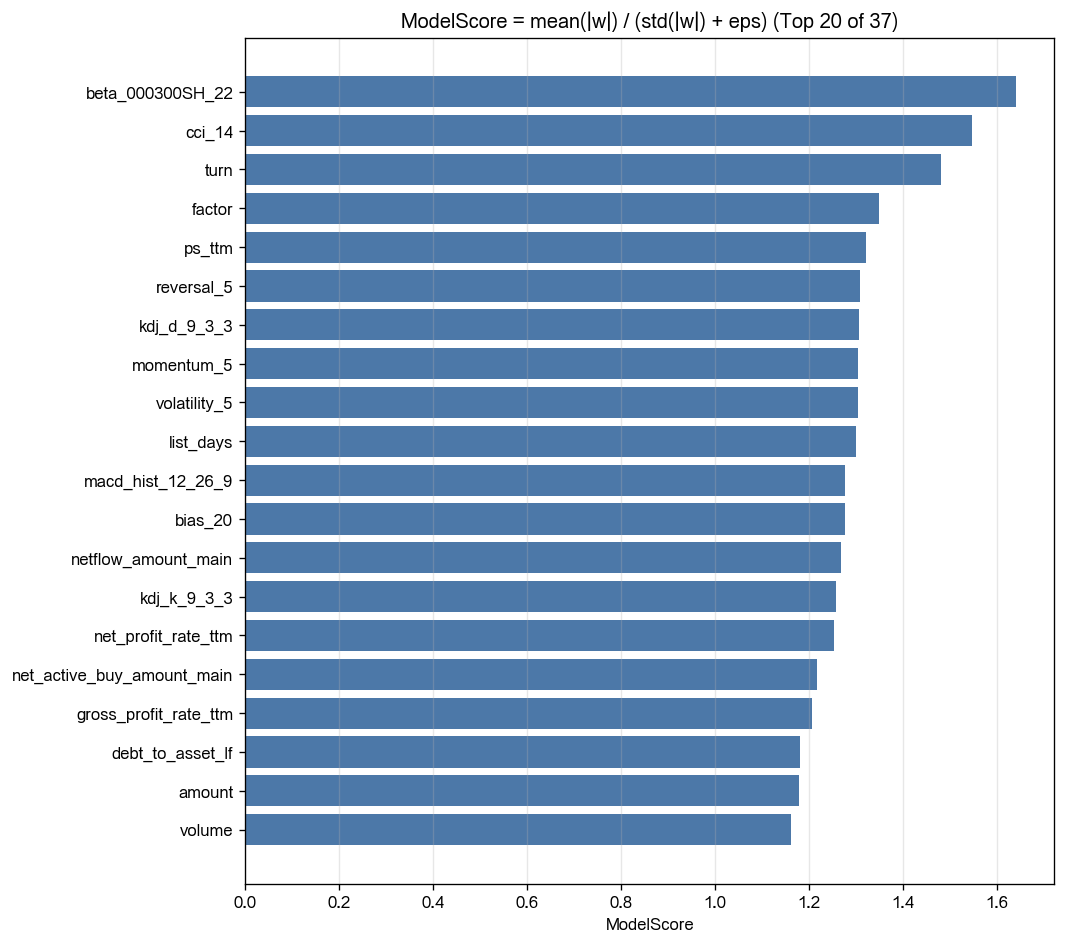
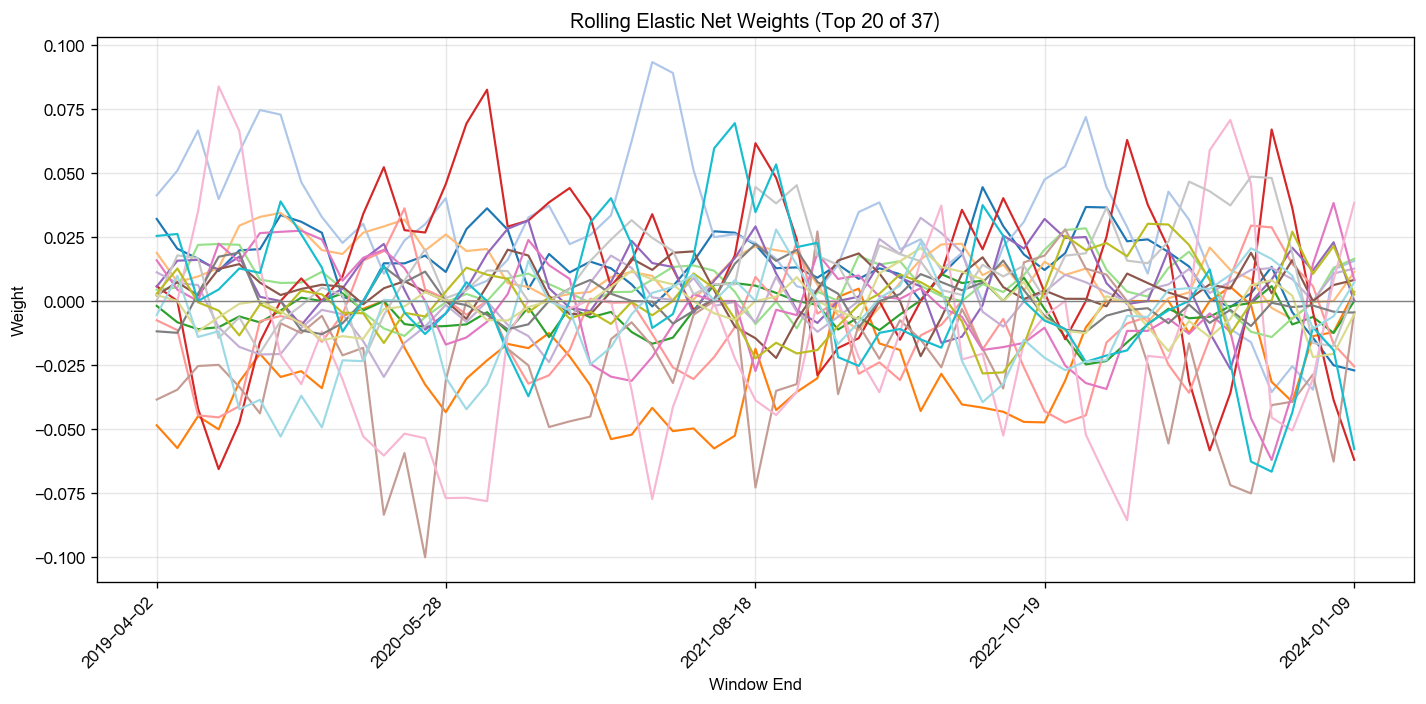
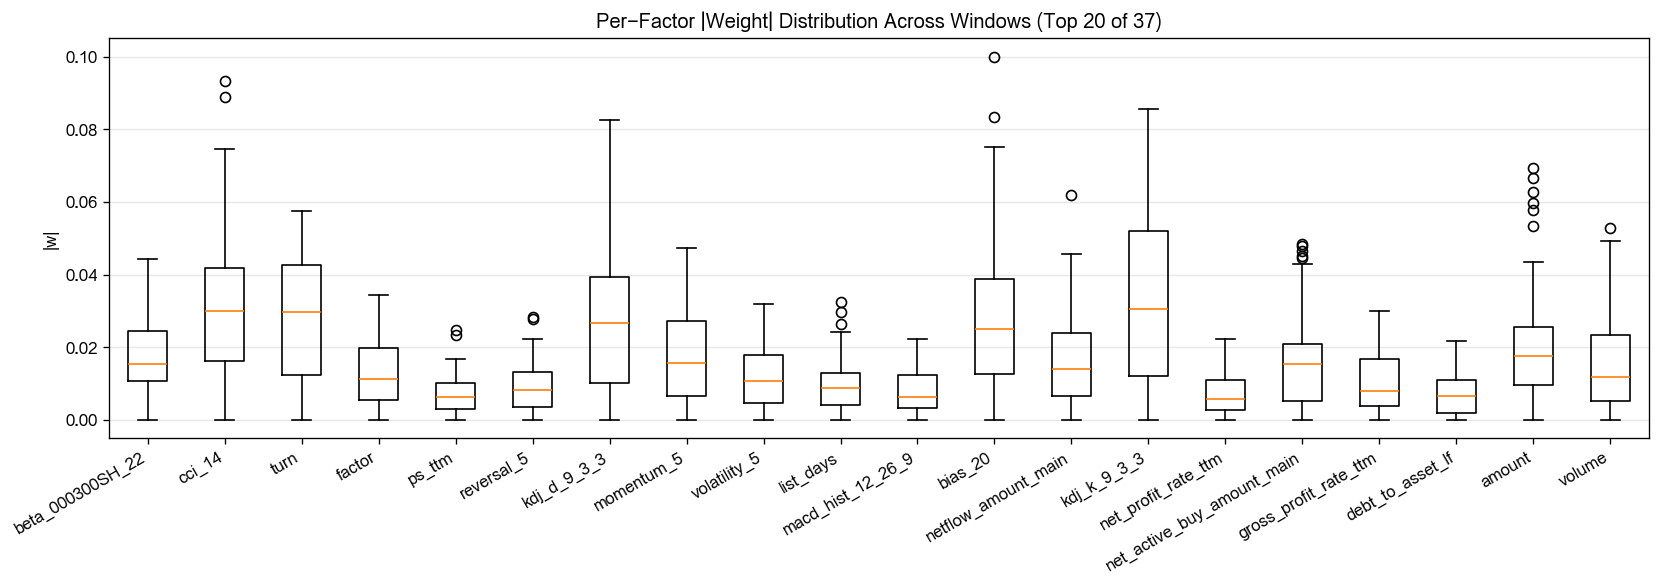
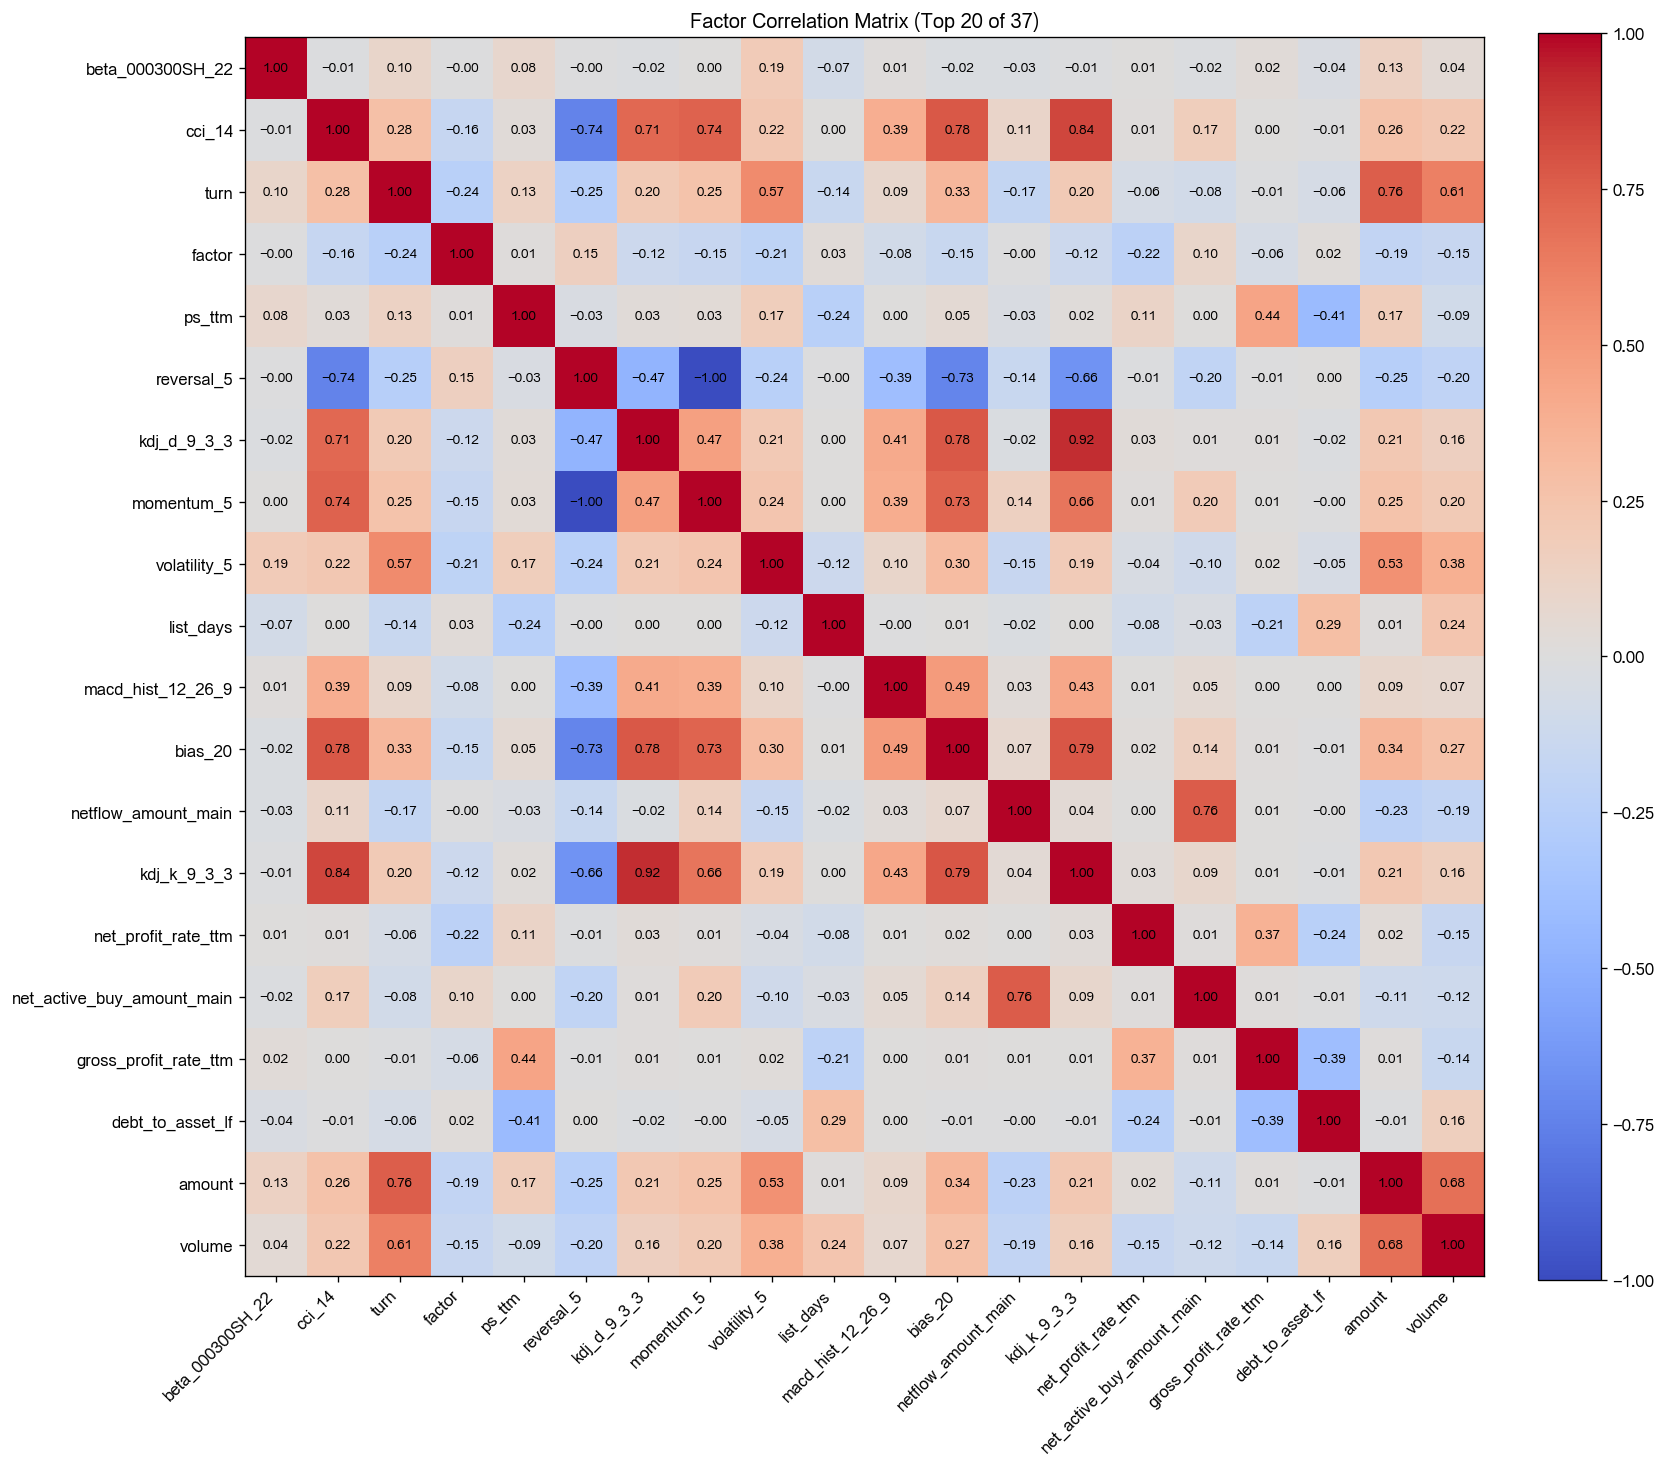

[2026-07-10 13:19:08] [warning  ] 返回的Outputs实例(size=184224780) 大于 64K, 将不会被缓存
[2026-07-10 13:19:08] [info     ] bigalpha_eval.v4 运行完成 [405.253s].


In [3]:
def main(datasources, start_date, end_date):
    """
    因子构建主函数 - 内存优化版
    修复项：
      1. 删除 del SQL别名的NameError
      2. cte_daily GROUP BY 改为真正日频聚合（核心内存修复）
      3. 删除SQL中未使用的 weight_bid/weight_ask/returns 计算
      4. 财务填充改用 merge 替代 groupby+reindex
      5. float64 → float32 降精度省内存
    输出固定三列 ['date', 'instrument', 'factor']，不含inf无穷值
    """
    import pandas as pd
    import dai
    import numpy as np

    bar1m = datasources["bar1m"]
    financial_table = datasources["financial"]
    LOOKBACK_DAYS = 36
    query_start_date = pd.to_datetime(start_date) - pd.Timedelta(days=LOOKBACK_DAYS)
    query_start_str = query_start_date.strftime("%Y-%m-%d")

    # ========== 前置：读取中证1000股票池 ==========
    stk_pool_all = dai.query(
        "SELECT DISTINCT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [query_start_str, end_date]},
        compression=True
    ).df()
    pool_instr_list = stk_pool_all["instrument"].unique().tolist()
    instr_filter = "','".join(pool_instr_list)

    # ========== 步骤3：盘口聚合SQL - 修复GROUP BY + 删除无用计算 ==========
    ob_sql = f"""
    WITH cte_bar1m AS (
    SELECT
        date, instrument,
        volume AS vol_min,
        amount AS amount_min,
        close AS close_min,
        strftime('%Y-%m-%d', date) as trading_day,
        (ask_price1 + bid_price1) / 2 as mid_price,
        COALESCE(bid_volume1,0)+COALESCE(bid_volume2,0)+COALESCE(bid_volume3,0) AS sum_bid_size,
        COALESCE(ask_volume1,0)+COALESCE(ask_volume2,0)+COALESCE(ask_volume3,0) AS sum_ask_size
    FROM {bar1m}
    WHERE ask_price1 > 0 AND bid_price1 > 0
      AND instrument IN ('{instr_filter}')
    ),
    cte_daily AS (
        SELECT
            CAST(trading_day AS DATETIME) AS date,
            instrument,
            SUM(vol_min)      AS vol_day,
            SUM(amount_min)   AS amount_day,
            LAST(close_min)   AS close_day,
            SUM(sum_bid_size) AS sum_bid_size,
            SUM(sum_ask_size) AS sum_ask_size
        FROM cte_bar1m
        GROUP BY instrument, trading_day
    )
    SELECT date, instrument, vol_day, amount_day, close_day, sum_bid_size, sum_ask_size
    FROM cte_daily
    """
    ob_day = dai.query(ob_sql, filters={"date": [query_start_str, end_date]}, compression=True).df()

    # float32 降精度，内存减半
    for c in ["vol_day", "amount_day", "close_day", "sum_bid_size", "sum_ask_size"]:
        ob_day[c] = ob_day[c].astype(np.float32)

    print(f"【步骤3完成】盘口日频聚合行数：{len(ob_day)}")

    # ========== 步骤4：TTM ROE - 拆成两次查询避免PRUNE JOIN的Arrow字典编码报错 ==========
    print("\n【步骤4】读取财务TTM-ROE数据并填充日频")

    # 单独查 TTM 净利润
    np_ttm_sql = f"""
    SELECT DISTINCT date, instrument, net_profit_to_parent_shareholders as np_ttm
    FROM {financial_table}
    WHERE category='ttm' AND shift=0
      AND instrument IN ('{instr_filter}')
      AND net_profit_to_parent_shareholders IS NOT NULL
    """
    np_ttm_df = dai.query(np_ttm_sql, filters={'date': [query_start_str, end_date]}, compression=True).df()
    np_ttm_df["np_ttm"] = np_ttm_df["np_ttm"].astype(np.float32)

    # 单独查 LF 净资产
    equity_lf_sql = f"""
    SELECT DISTINCT date, instrument, total_equity_to_parent_shareholders as equity_lf
    FROM {financial_table}
    WHERE category='lf' AND shift=0
      AND instrument IN ('{instr_filter}')
      AND total_equity_to_parent_shareholders > 0
    """
    equity_lf_df = dai.query(equity_lf_sql, filters={'date': [query_start_str, end_date]}, compression=True).df()
    equity_lf_df["equity_lf"] = equity_lf_df["equity_lf"].astype(np.float32)

    # pandas 侧 merge + 安全除法，替代 PRUNE JOIN + fdiv
    financial_df = np_ttm_df.merge(equity_lf_df, on=["date", "instrument"], how="inner")
    financial_df["roe_ttm"] = financial_df["np_ttm"] / financial_df["equity_lf"].replace(0, np.nan)
    financial_df = financial_df[["date", "instrument", "roe_ttm"]].dropna(subset=["roe_ttm"])
    del np_ttm_df, equity_lf_df

    # 用股票池 merge 做前向填充，替代 groupby+reindex（省去生成全交易日索引）
    # 原理：stk_pool_all 已包含所有 (date, instrument) 对，左联财务后 ffill 即可
    fin_daily = stk_pool_all.merge(financial_df, on=["date", "instrument"], how="left")
    fin_daily = fin_daily.sort_values(["instrument", "date"]).reset_index(drop=True)
    fin_daily["roe_ttm"] = fin_daily.groupby("instrument")["roe_ttm"].ffill()
    fin_daily = fin_daily.dropna(subset=["roe_ttm"])
    print(f"【步骤4完成】财务填充后日频行数：{len(fin_daily)}")
    del financial_df  # 释放原始财报

    # ========== 步骤5 多表合并 ==========
    print("\n【步骤5】多表合并")
    df = ob_day.merge(fin_daily, on=["date", "instrument"], how="left")
    df = df.drop_duplicates(subset=["date", "instrument"], keep="first")
    # 内联股票池缩量
    df = pd.merge(df, stk_pool_all, how='inner', on=['date', 'instrument'])
    print(f"【步骤5完成】合并+成分股过滤后行数：{len(df)}")
    del ob_day, fin_daily, stk_pool_all

    # ========== 步骤6 子因子计算 ==========
    print("\n【步骤6】计算子因子")
    df = df.sort_values(["instrument", "date"]).reset_index(drop=True)
    df["vol_prev20_mean"] = df.groupby("instrument")["vol_day"].transform(
        lambda s: s.shift(1).rolling(20, min_periods=5).mean()
    )
    df["liquidity_spike"] = np.log1p(df["vol_day"]) - np.log1p(df["vol_prev20_mean"].replace(0, np.nan))

    df["ob_ratio"] = df["sum_bid_size"] / (df["sum_ask_size"] + 1e-9)
    df["ob_imbalance"] = np.log1p(df["ob_ratio"])

    # roe 列已在 fin_daily merge 时带入
    print("【步骤6完成】全部子因子计算完毕")

    # ========== 步骤7 截面标准化、合成总因子 ==========
    def winsorize(s, low_q=0.01, high_q=0.99):
        lo = s.quantile(low_q)
        hi = s.quantile(high_q)
        return s.clip(lower=lo, upper=hi)

    def process_day(group):
        cols = ["liquidity_spike", "ob_imbalance", "roe_ttm"]
        for col in cols:
            if group[col].isnull().all():
                group[f"{col}_z"] = np.nan
                continue
            group[col] = group[col].fillna(group[col].median())
            group[col] = winsorize(group[col])
            mu = group[col].mean()
            sigma = group[col].std(ddof=0)
            if sigma == 0 or np.isnan(sigma):
                group[f"{col}_z"] = 0.0
            else:
                group[f"{col}_z"] = (group[col] - mu) / sigma
        z_cols = ["liquidity_spike_z", "ob_imbalance_z", "roe_ttm_z"]
        group["factor"] = group[z_cols].mean(axis=1) * -1
        return group

    print("\n【步骤7】截面标准化合成总因子")
    df = df.groupby("date", group_keys=False).apply(process_day).reset_index(drop=True)

    # ========== 截断输出时间区间 ==========
    df["date"] = pd.to_datetime(df["date"])
    start_dt = pd.to_datetime(start_date)
    end_dt = pd.to_datetime(end_date)
    df = df[(df["date"] >= start_dt) & (df["date"] <= end_dt)].copy()

    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["factor"])

    out = df[["date", "instrument", "factor"]].copy()
    out["date"] = out["date"].dt.strftime("%Y-%m-%d")
    print("===== 全部流程执行完毕，返回因子表 =====")
    return out


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {
        "financial": "bigalpha_2026_financial",
        "bar1m": "bigalpha_2026_stock_bar1m",
    }
    start_date = "2019-01-01 00:00:00"
    end_date = "2024-1-31 23:59:59"

    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info(f"读取因子库用于回归评估")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
